In [49]:
from skimage.io import imread
import numpy as np
from scipy.io import loadmat
from matplotlib import pyplot as plt
import time


In [50]:
rootfolder = '.'


Useful function for plot a 2D dictionary

In [51]:
def get_dictionary_img(D):
    M, N = D.shape
    p = int(round(np.sqrt(M)))
    nnn = int(np.ceil(np.sqrt(N)))
    bound = 2
    img = np.ones((nnn*p+bound*(nnn-1), nnn*p+bound*(nnn-1)))
    for i in range(N):
        m = np.mod(i, nnn)
        n = int((i-m)/nnn)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

Define a function that implements the OMP

In [52]:
def OMP(s, D, L, tau):
    # Initalize
    N = D.shape[1]
    r = s
    x_OMP = np.zeros(N) 
    omega = []

    while np.linalg.norm(r) > tau and np.count_nonzero(x_OMP) < L: #STOPPING CRITERIA:

        # SWEEP STEP: look for the column of D that matches at best noisySignal
        # compute the residual w.r.t. each column of D
        e = np.zeros(N)
        for j in range(N):
            e[j] = np.linalg.norm(r)**2 - (r @ D[:, j])**2

        # find the column of D that matches at best r
        jStar = np.argmin(e)

        # UPDATE the support set with the jStar coefficient
        omega.append(jStar)
        # update the coefficients by solving the least square problem min ||D_omega x - s ||


        Xw = np.linalg.inv(D[:, omega].T @ D[:, omega]) @ D[:, omega].T @ s

        x_OMP = np.zeros(N)
        x_OMP[omega] = Xw

        # update the residual
        r = s - D @ x_OMP
    
    return x_OMP
#   

Load the image and rescale it in $[0,1]$

In [53]:
img = imread(f'{rootfolder}/data/peppers256.png') / 255
# img = imread(f'{rootfolder}/data/barbara.png') / 255
# img = imread(f'{rootfolder}/data/Lena512.png') / 255

imsz = img.shape

# patch size
p = 8

# number of elements in the patch
M = p ** 2


Corrupt the image with white gaussian noise

In [54]:
sigma_noise = 20/255
noisy_img = img + np.random.normal(size=imsz) * sigma_noise

Percentage of removed pixel

In [55]:
perc_of_removed_pixels = 0.25

Arbitrarily remove pixels setting them to zero

In [56]:
# create a vector with all the indexes of the image
idx= np.arange(img.size)

# shuffle it and take the target percentage of indexes
np.random.shuffle(idx) 
TargetPerc = img.size * perc_of_removed_pixels

msk = np.ones(img.size)
# the mask is 0 for the chosen idx, 1 elsewhere
When_stop = int(img.size * perc_of_removed_pixels)
for i in range(When_stop):
    #print(i, idx[i])
    msk[idx[i]] = 0
msk = msk.reshape(imsz)
# apply the mask: set to 0 some elements in the noisy image
noisy_img = noisy_img * msk


Compute the psnr of the noisy input

In [57]:
psnr_noisy = 10 * np.log10(1/np.mean((noisy_img - img)**2))


Text(0.5, 1.0, 'Dead pixels')

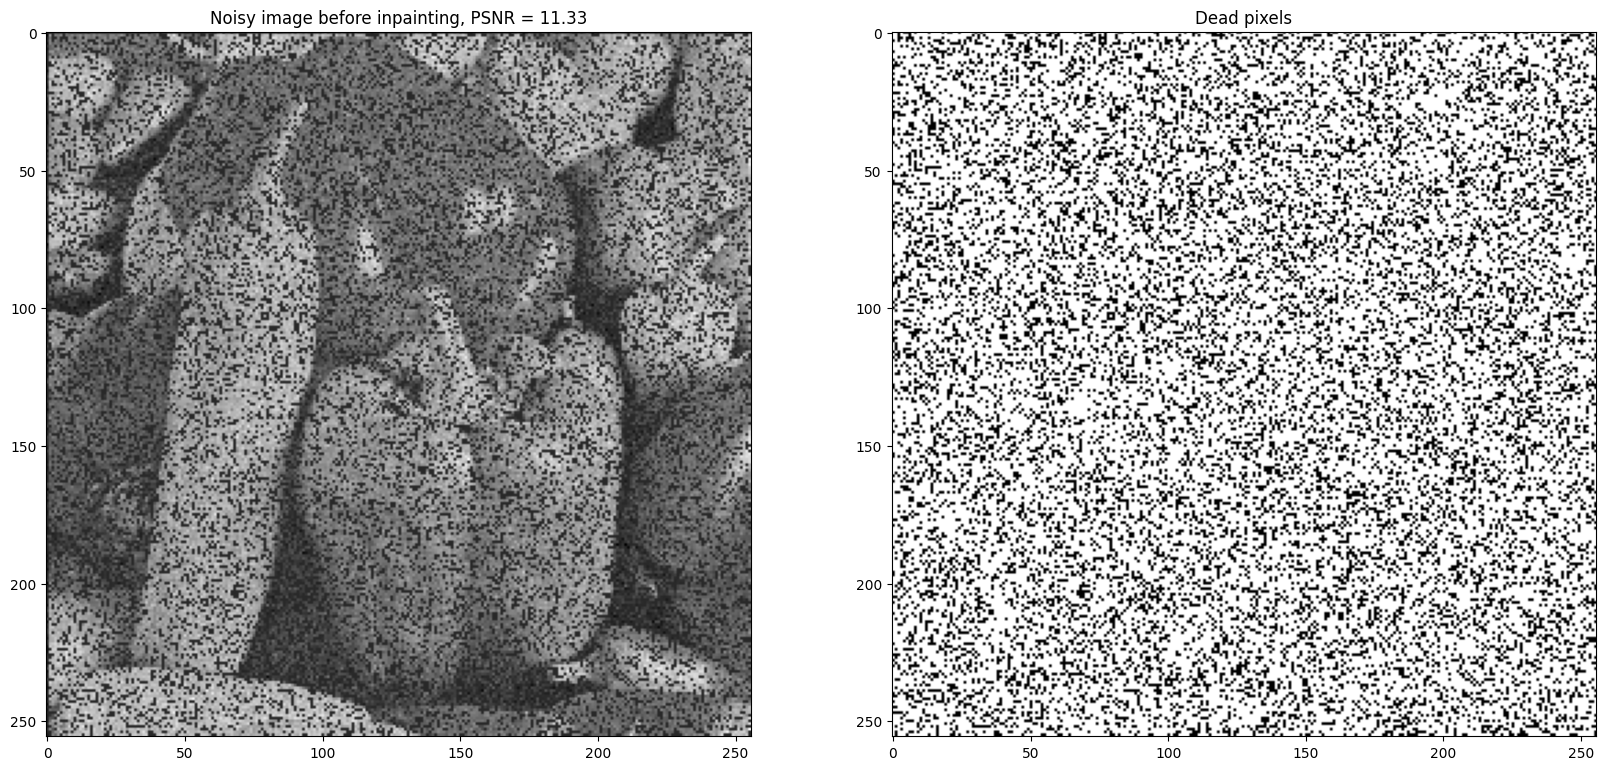

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(noisy_img, cmap='gray')
ax[0].set_title(f'Noisy image before inpainting, PSNR = {psnr_noisy:.2f}')

ax[1].imshow(msk, cmap='gray')
ax[1].set_title(f'Dead pixels')


Load and display the dictionary learned from patches

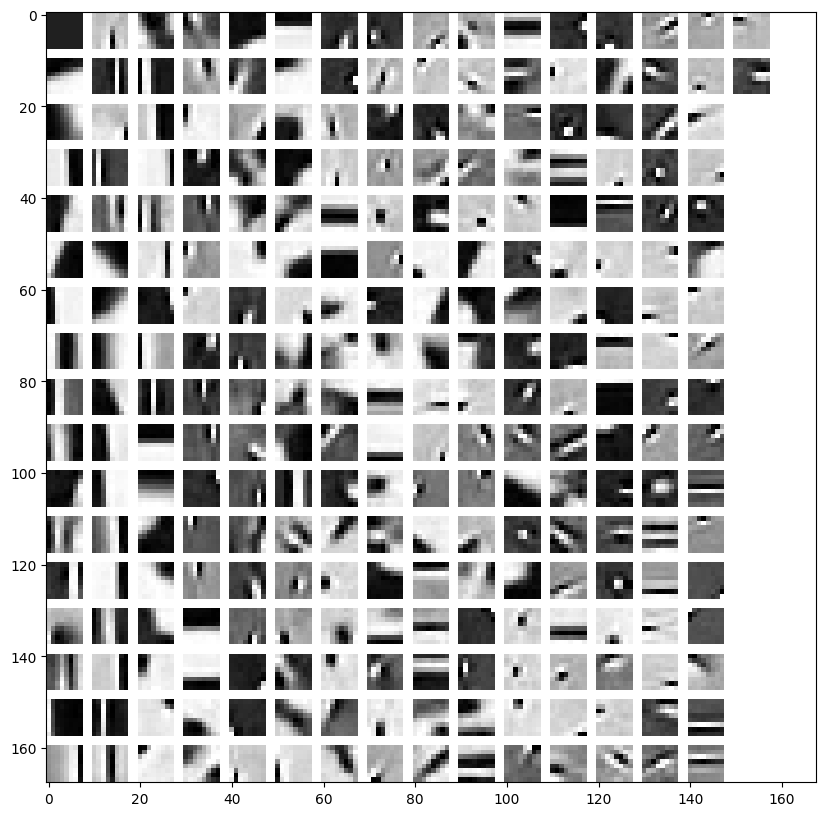

In [59]:
D = loadmat(f'{rootfolder}/data/dict_nat_img.mat')['D']

# add a constant atom to D, KSVD was trained over patches with zero mean - and normalize it
# UPDATE D

atom = np.ones(M)
atom = atom / np.linalg.norm(atom)
D = np.hstack((atom.reshape(-1,1), D))


# display the dictionary
D_img = get_dictionary_img(D)

plt.figure(figsize=(10,10))
plt.imshow(D_img, cmap='gray')

Inpainting
----------


In [60]:
# SET stopping criteria of OMP
# orthogonal matching pursuit uses sparsity and errors as stopping criteria
L = M / 2

# initialize the estimated image
img_hat = np.zeros_like(img)

# initialize the weight matrix
weights = np.zeros_like(img)

# define the step (=p for non overlapping paches)
STEP = 2 # STEP = 1 might be very time consuming, start with larger STEP

Operate patchwise

In [61]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # extrach the patch with the top left corner at pixel (ii, jj)
        s = noisy_img[i:i+p, j:j+p]

        # patch extracted from the mask
        m = msk[i:i+p, j:j+p]

        # design the projection operator over the current patch
        proj = np.diag(m.reshape(-1))

        # tau should be proportional to the number of pixels remaining in the patch
        tau = 1.15 * sigma_noise * np.sqrt(np.count_nonzero(m))

        # sparse coding w.r.t. PD the inpainted dictionary using L and tau as stopping criteria
        x = OMP(s.reshape(-1), proj @ D, L, tau)

        # reconstruction: synthesis w.r.t. D the dictionary yielding sparse representation
        s_hat = D @ x

        # use uniform weights for aggregation
        w = 1

        # put the denoised patch into the estimated image using uniform weights
        # UPDATE img_hat
        img_hat[i:i+p, j:j+p] += s_hat.reshape((p,p))

        # store the weight of the current patch in the weight matrix
        # UPDATE weights
        weights [i:i+p, j:j+p] +=1


Normalize the estimated image with the computed weights

In [62]:
img_hat = img_hat/weights

Compute the psnr of the estimated image

In [63]:
psnr_hat = 10 *np.log10(1/np.mean((img_hat-img)**2))

Text(0.5, 1.0, 'Estimated Image,\nPSNR = 29.25')

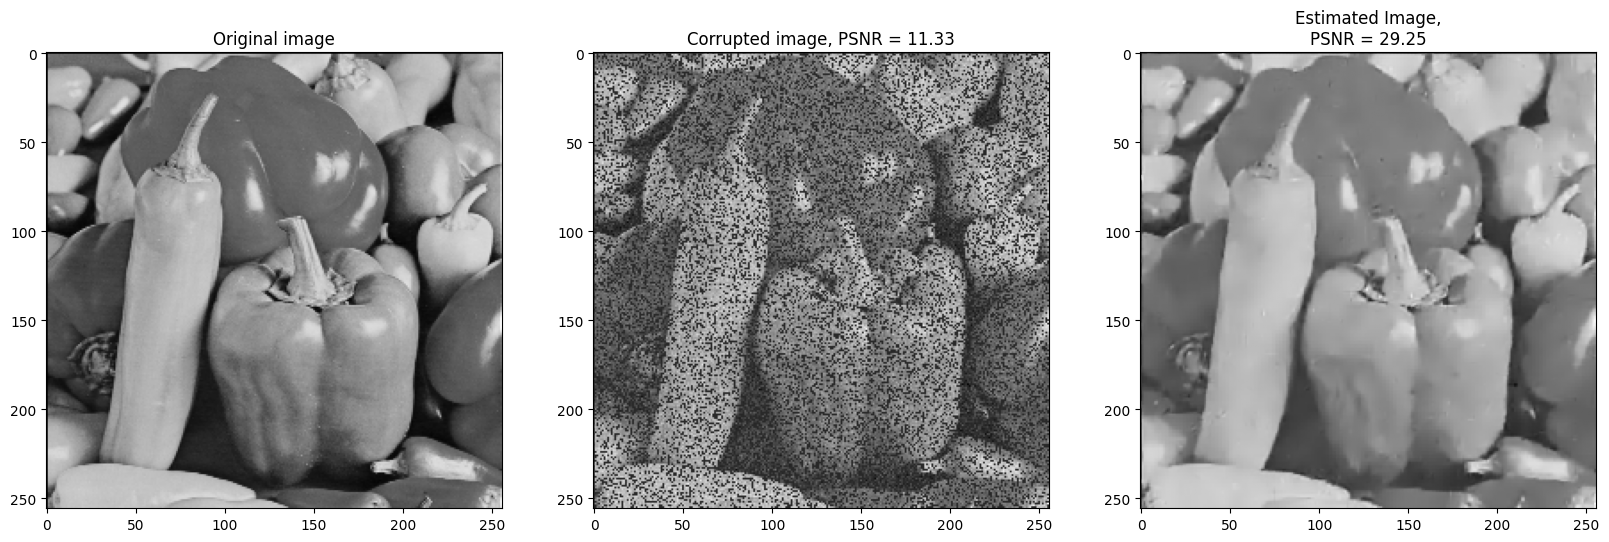

In [65]:
fig, ax = plt.subplots(1, 3, figsize=(20, 10))

ax[0].imshow(img, cmap='gray')
ax[0].set_title(f'Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Corrupted image, PSNR = {psnr_noisy:.2f}')

ax[2].imshow(img_hat, cmap='gray')
ax[2].set_title(f'Estimated Image,\nPSNR = {psnr_hat:.2f}')
